In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [19]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [22]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

df[["Age","AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult


In [23]:
age_survival = df.groupby("AgeGroup")["Survived"].mean()*100

print(age_survival)

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    33.109620
Adult          42.323651
Senior         34.375000
Name: Survived, dtype: float64


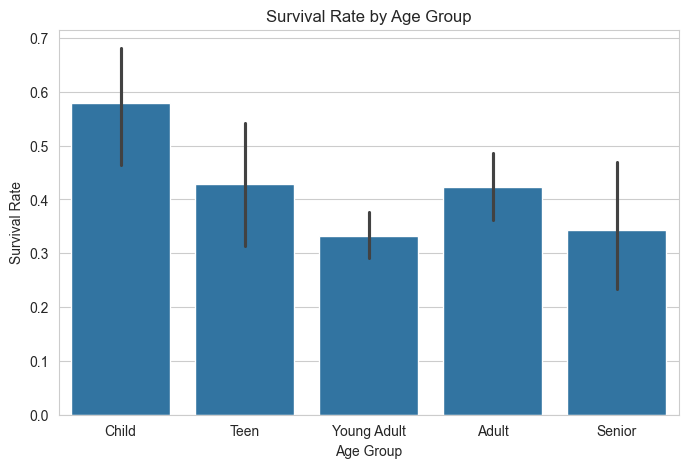

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(x="AgeGroup", y="Survived", data=df)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

In [25]:
embarked_survival = df.groupby("Embarked")["Survived"].mean()*100

print(embarked_survival)

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


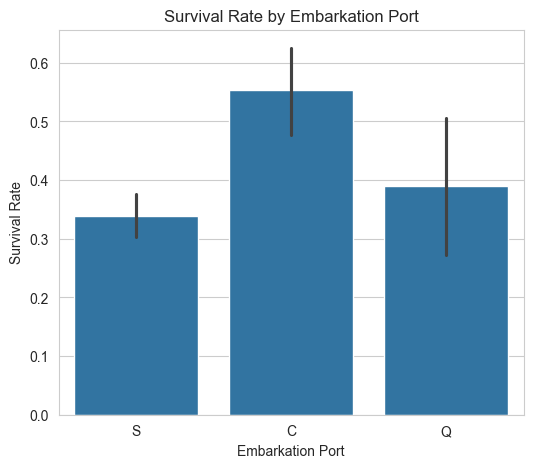

In [26]:
plt.figure(figsize=(6,5))

sns.barplot(x="Embarked", y="Survived", data=df)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")

plt.show()

In [27]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [28]:
family_survival = df.groupby("FamilySize")["Survived"].mean()*100

print(family_survival)

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


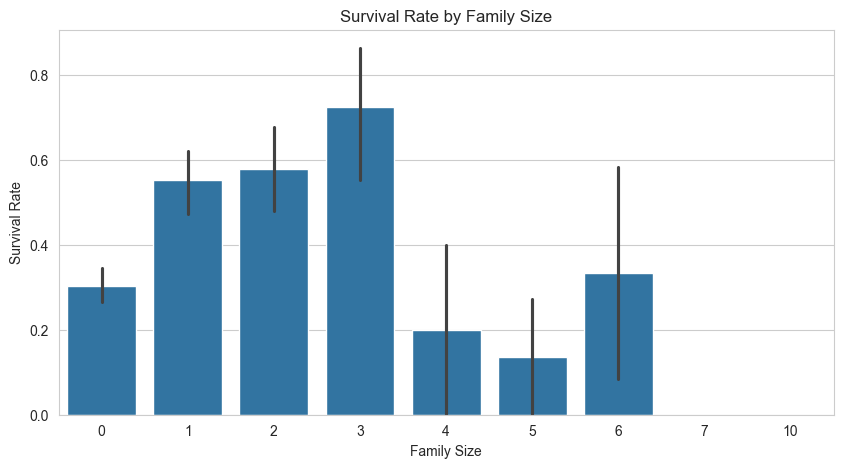

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(x="FamilySize", y="Survived", data=df)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

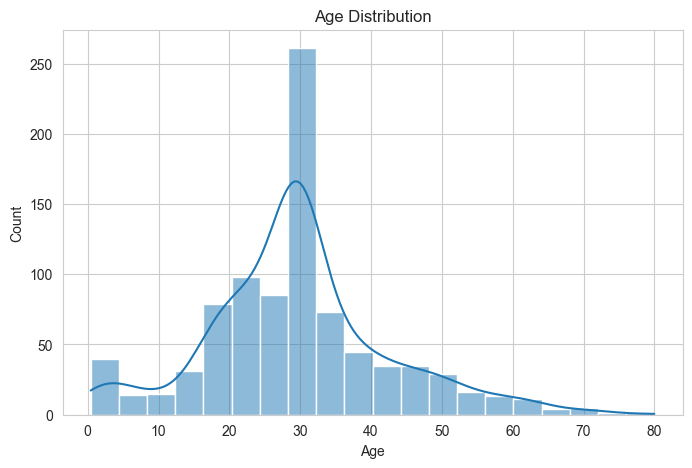

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()



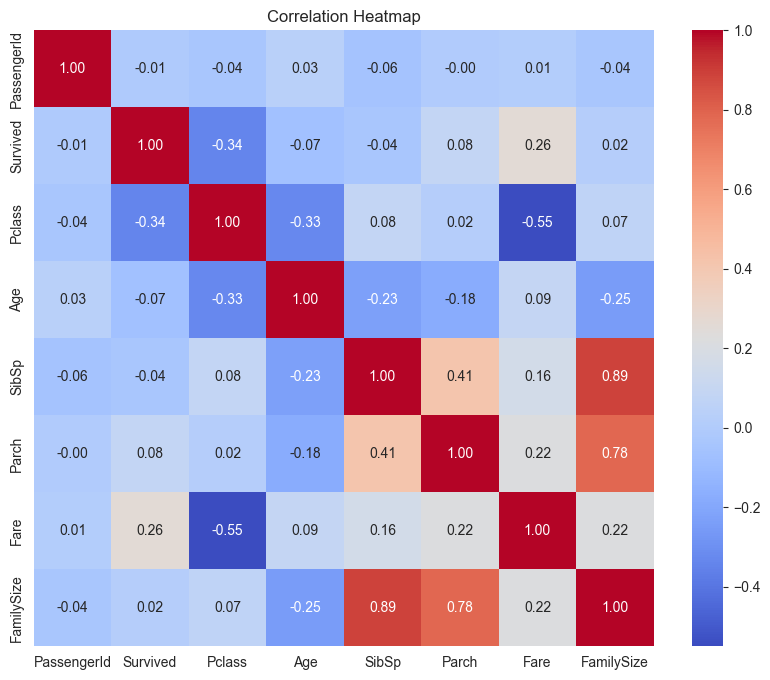

In [31]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

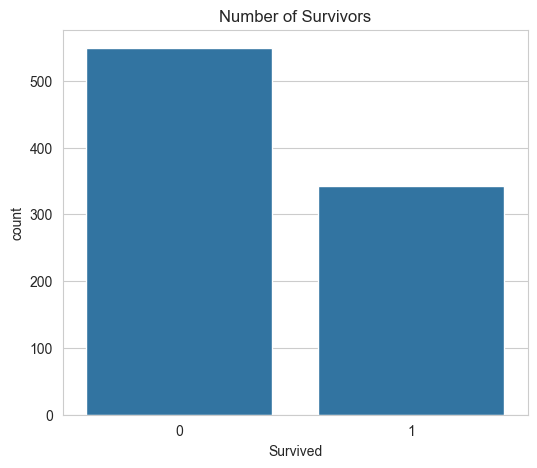

In [32]:
plt.figure(figsize=(6,5))

sns.countplot(x="Survived", data=df)

plt.title("Number of Survivors")

plt.show()

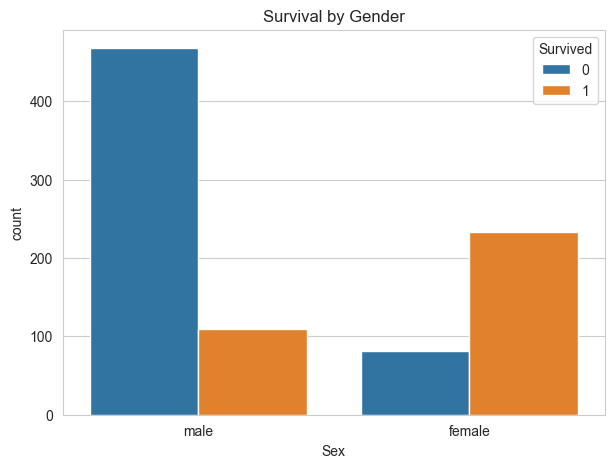

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

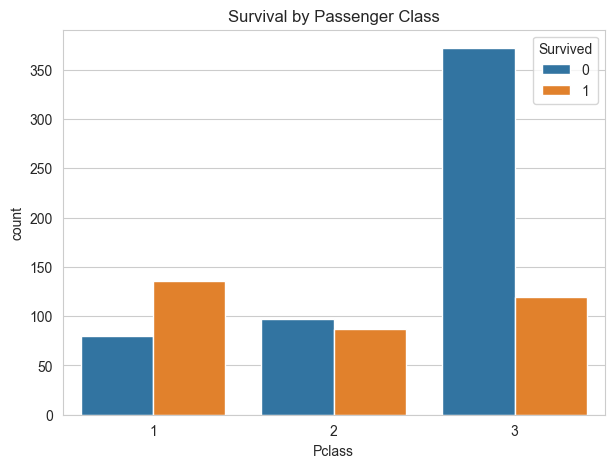

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()